In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("output.csv")

print("Total Records:", len(df))


Total Records: 90


In [2]:

df["carrier"] = df["carrier"].fillna("UNKNOWN")
df["environment"] = df["environment"]

df["voiceQuality"] = df["voiceQuality"]

df["audioIssues"] = df["audioIssues"].fillna("")

df["duration_sec"] = df["callDuration"] / 1000


Indoor vs Outdoor Records by Carrier:
environment  INDOOR  OUTDOOR
carrier                     
AIRTEL           42        6
JIO               9        2
Vi India          5        1


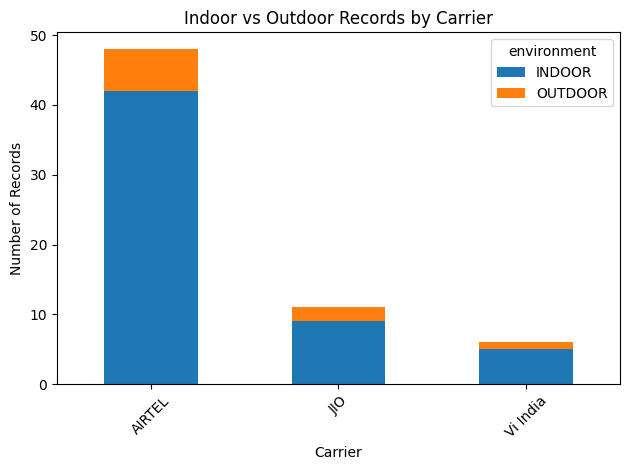

In [4]:

indoor_outdoor = df.groupby(["carrier", "environment"]).size().unstack(fill_value=0)
print("\nIndoor vs Outdoor Records by Carrier:")
print(indoor_outdoor)
indoor_outdoor.plot(kind="bar", stacked=True)
plt.title("Indoor vs Outdoor Records by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("indoor_outdoor_by_carrier.png")
plt.show() 


Average Voice Quality by Carrier:
carrier
AIRTEL      4.479167
JIO         4.272727
Vi India    4.125000
Name: voiceQuality, dtype: float64


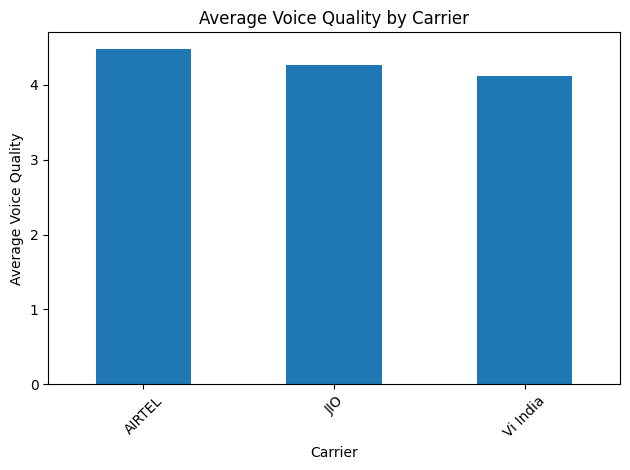

In [5]:

#avg voice quality by carrier
avg_voice_quality = df.groupby("carrier")["voiceQuality"].mean().sort_values(ascending=False)


print("\nAverage Voice Quality by Carrier:")
print(avg_voice_quality)

avg_voice_quality.plot(kind="bar")
plt.title("Average Voice Quality by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Voice Quality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("avg_voice_quality_by_carrier.png")
plt.show()


Call Drop Rate by Carrier:
carrier
JIO         0.090909
AIRTEL      0.017857
Vi India    0.000000
dtype: float64


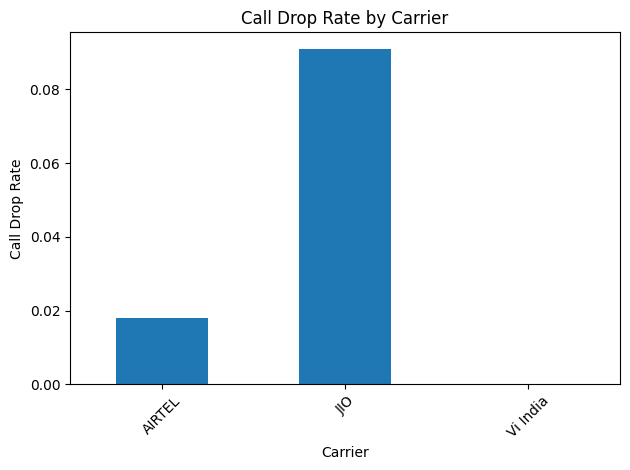

In [6]:
#drop rate by carrier
drop_rate = df[df["audioIssues"] == "CALL_DROPPED"].groupby("carrier").size() / df.groupby("carrier").size()

drop_rate = drop_rate.fillna(0)
print("\nCall Drop Rate by Carrier:")
print(drop_rate.sort_values(ascending=False))

drop_rate.plot(kind="bar")
plt.title("Call Drop Rate by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Call Drop Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("drop_rate_by_carrier.png")
plt.show()


Average Call Duration (sec) by Carrier:
carrier
AIRTEL      217.719768
JIO         106.689500
Vi India    460.910917
Name: duration_sec, dtype: float64


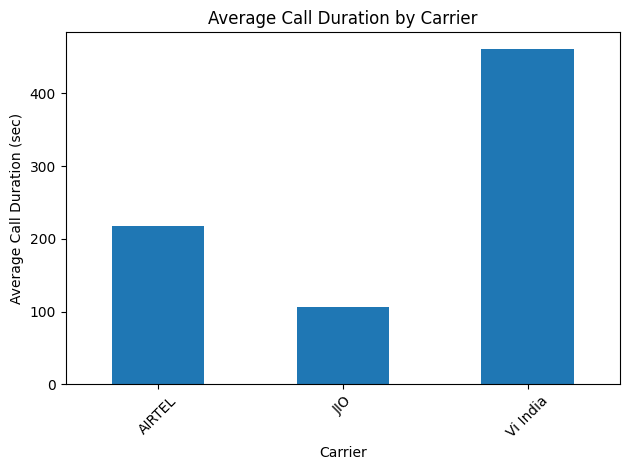

In [8]:
#change order


avg_duration = df.groupby("carrier")["duration_sec"].mean().sort_values(ascending=False)

#order airtel jio vi
avg_duration = avg_duration.reindex(["AIRTEL", "JIO", "Vi India"])
print("\nAverage Call Duration (sec) by Carrier:")
print(avg_duration)
avg_duration.plot(kind="bar")
plt.title("Average Call Duration by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Call Duration (sec)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("avg_duration_by_carrier.png")
plt.show()

AUDIO ISSUES


Audio Issues Distribution:
audioIssues
CALL_PERFECT               49
UNKNOWN                    28
OTHER_COULD_NOT_HEAR_ME     5
COULD_NOT_HEAR_OTHER        3
CALL_DROPPED                3
BACKGROUND_NOISE            2
Name: count, dtype: int64


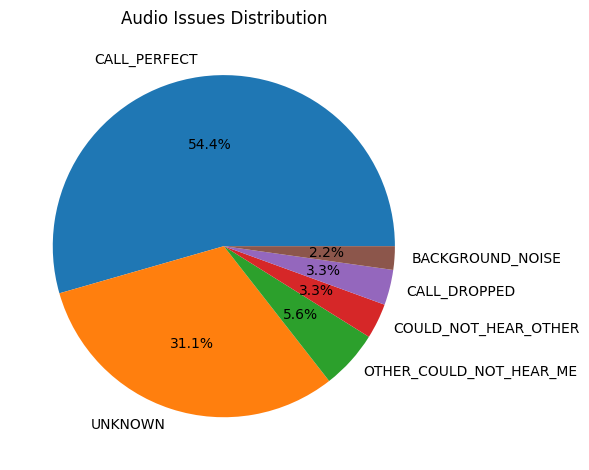

In [9]:

df["audioIssues"] = df["audioIssues"].replace("", "UNKNOWN")
audio_issue_counts = df["audioIssues"].value_counts()
print("\nAudio Issues Distribution:")
print(audio_issue_counts)
audio_issue_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Audio Issues Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("audio_issues_distribution+pie.png")
plt.show()


Audio Issues Distribution for JIO:
audioIssues
UNKNOWN                 11
CALL_PERFECT             8
CALL_DROPPED             2
COULD_NOT_HEAR_OTHER     1
Name: count, dtype: int64


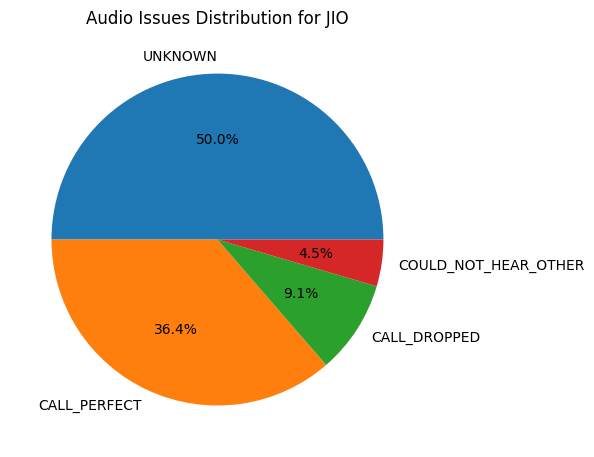


Audio Issues Distribution for AIRTEL:
audioIssues
CALL_PERFECT               35
UNKNOWN                    12
OTHER_COULD_NOT_HEAR_ME     5
BACKGROUND_NOISE            2
COULD_NOT_HEAR_OTHER        1
CALL_DROPPED                1
Name: count, dtype: int64


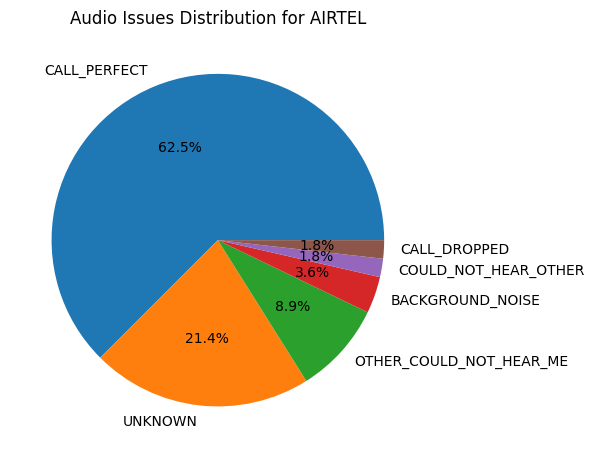


Audio Issues Distribution for Vi India:
audioIssues
CALL_PERFECT            6
UNKNOWN                 5
COULD_NOT_HEAR_OTHER    1
Name: count, dtype: int64


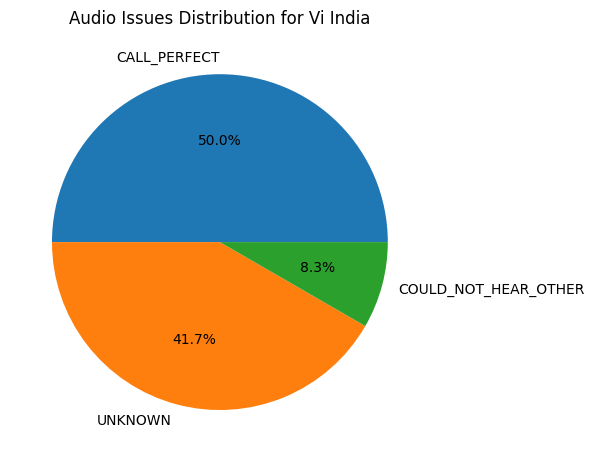

In [10]:

for carrier in df["carrier"].unique():
    carrier_data = df[df["carrier"] == carrier]
    carrier_audio_issue_counts = carrier_data["audioIssues"].value_counts()
    plt.figure(figsize=(6,6))
    print(f"\nAudio Issues Distribution for {carrier}:")
    print(carrier_audio_issue_counts)
    carrier_audio_issue_counts.plot(kind="pie", autopct="%1.1f%%")
    plt.title(f"Audio Issues Distribution for {carrier}")
    plt.ylabel("")

    plt.tight_layout()
    plt.savefig(f"audio_issues_distribution_{carrier}.png")
    plt.show()

Network Generation

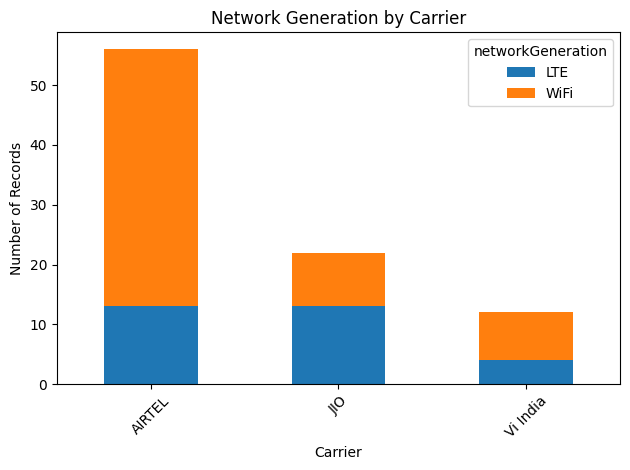

In [11]:

netw = df.groupby(["carrier", "networkGeneration"]).size().unstack(fill_value="UNKNOWN")
netw.plot(kind="bar", stacked=True)
plt.title("Network Generation by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("network_generation_by_carrier.png")
plt.show() 